# Lab 10: Visualizing Flow Data

Set Up

In [7]:
import pandas as pd

# Simulated migration dataset
data = {
    "origin": ["Alabama", "Alabama", "Alabama", "Texas", "Texas", "California", "California", "New York", "New York"],
    "destination": ["Texas", "Florida", "California", "California", "New York", "Texas", "Florida", "California", "Texas"],
    "year": [2010, 2010, 2010, 2011, 2011, 2012, 2012, 2012, 2012],
    "movers": [5000, 3000, 4000, 4500, 3800, 4200, 3900, 4100, 4700]
}
df = pd.DataFrame(data)
df.head()


,origin,destination,year,movers
0,Alabama,Texas,2010,5000
1,Alabama,Florida,2010,3000
2,Alabama,California,2010,4000
3,Texas,California,2011,4500
4,Texas,New York,2011,3800


1. Sankey Diagram (Origin → Destination)

In [8]:
import plotly.graph_objects as go

# Create unique labels
labels = list(pd.unique(df[['origin', 'destination']].values.ravel()))
label_map = {label: i for i, label in enumerate(labels)}

# Sankey links
sources = df['origin'].map(label_map)
targets = df['destination'].map(label_map)
values = df['movers']

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])
fig.update_layout(title_text="Migration Flow (Sankey Diagram)", font_size=10)
fig.show()


Dataset: Simulated migration data from 2010–2012, showing people moving between U.S. states.

Rows: 9

Columns: origin, destination, year, movers

Features Used:

origin, destination → Nodes

movers → Flow thickness

Insight:
California and Texas are frequent destinations, with high incoming migration from other states.

2. Alluvial Plot (Add Year as a 3rd stage: Year → Origin → Destination)

In [6]:
import plotly.express as px

# Sample for performance if needed
df_sample = df.sample(5000, random_state=42) if len(df) > 5000 else df.copy()

# Plot alluvial/parallel categories
fig = px.parallel_categories(
    df_sample,
    dimensions=['year', 'origin', 'destination'],
    color='movers',
    color_continuous_scale=px.colors.sequential.Plasma,
    labels={"year": "Year", "origin": "Origin State", "destination": "Destination State"}
)

fig.update_layout(title="Alluvial Plot: Year → Origin → Destination", font_size=10)
fig.show()


Dataset: Simulated migration data between U.S. states from 2010–2012.
Features:

year, origin, destination: Categorical flows

movers: Used for color scale (flow intensity)

Insight:
You can track how specific years are linked to migration routes. For example, 2012 shows high movement from California to Texas and Florida.

3. Chord Diagram (with Bokeh)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18992\2790745647.py:54: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



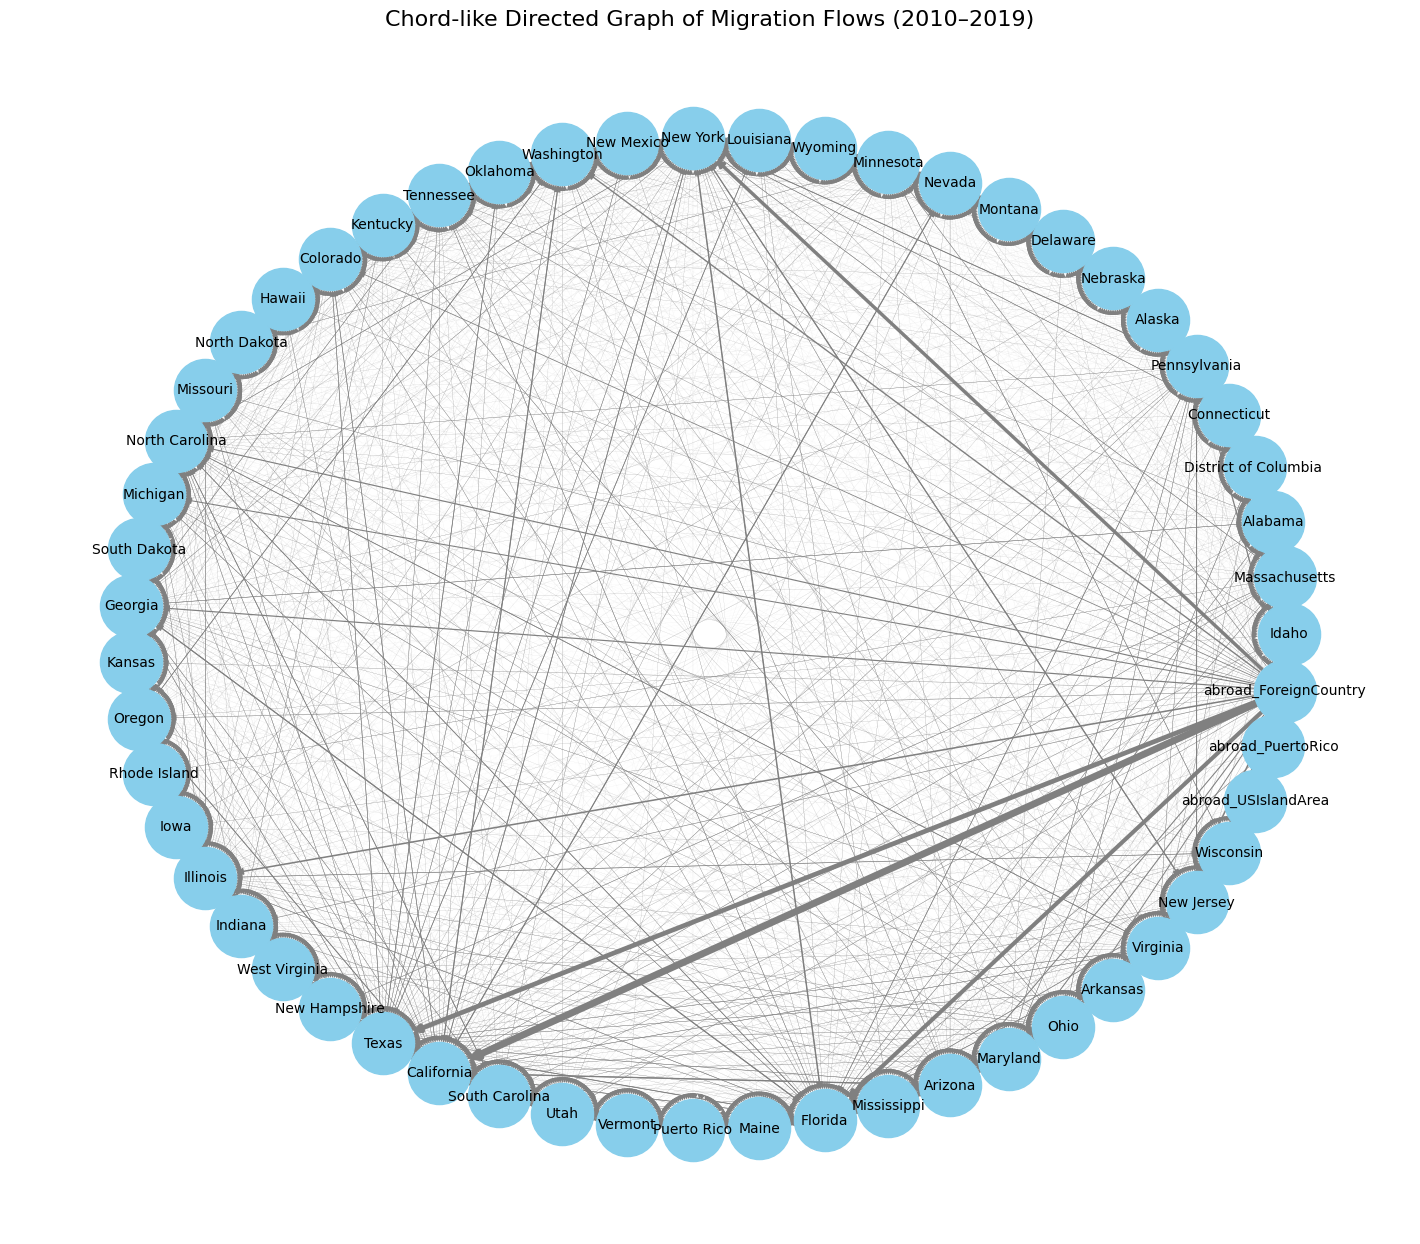

In [11]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("Datasets/Migration_Flows_from_2010_to_2019.csv")

# Rename columns for clarity
df = df.rename(columns={
    "from": "origin",
    "current_state": "destination",
    "number_of_people": "movers"
})

# Filter out zero movers
df = df[df['movers'] > 0]

# Create a directional flow matrix
states = list(set(df['origin'].tolist() + df['destination'].tolist()))
matrix = pd.DataFrame(0, index=states, columns=states)

for _, row in df.iterrows():
    matrix.loc[row['origin'], row['destination']] += row['movers']

# Create directed graph
G = nx.DiGraph()
for origin in matrix.index:
    for dest in matrix.columns:
        weight = matrix.loc[origin, dest]
        if weight > 0:
            G.add_edge(origin, dest, weight=weight)

# Plot with circular layout
plt.figure(figsize=(14, 12))
pos = nx.circular_layout(G)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

# Normalize weights for line thickness
norm_weights = np.array(weights) / max(weights) * 5

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    node_color='skyblue',
    arrows=True,
    width=norm_weights,
    edge_color='gray',
    font_size=10
)
plt.title("Chord-like Directed Graph of Migration Flows (2010–2019)", fontsize=16)
plt.tight_layout()
plt.show()


4. Directed Graph (Flow Network)

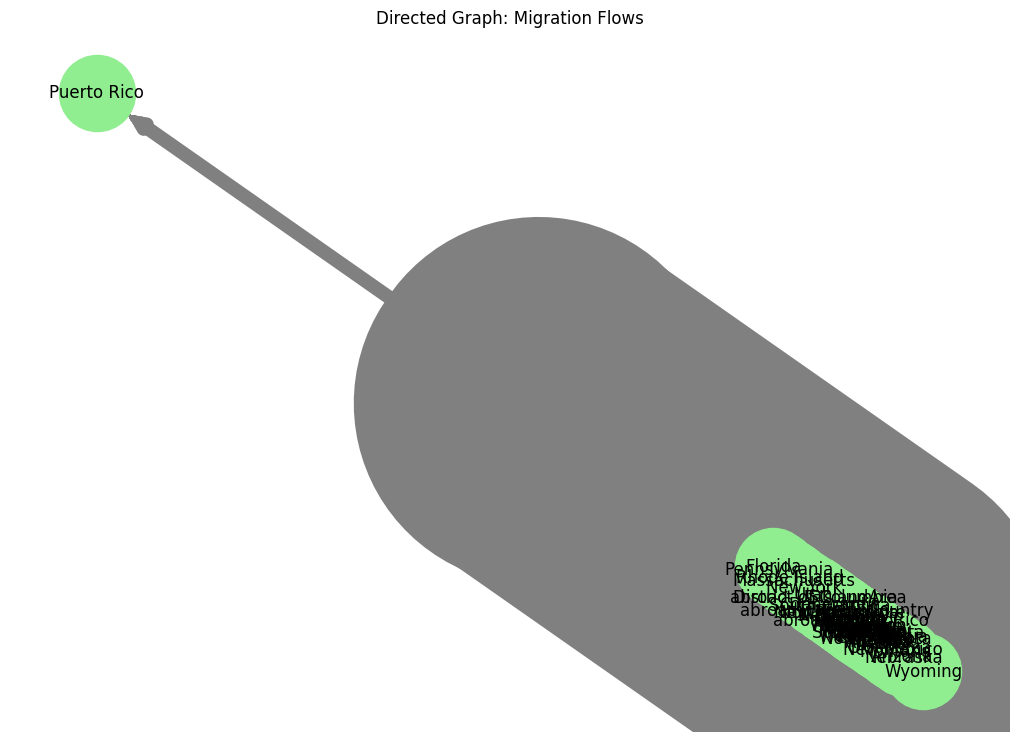

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Add edges with weights
for _, row in df.iterrows():
    G.add_edge(row['origin'], row['destination'], weight=row['movers'])

# Draw graph
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 7))
edges = G.edges(data=True)
weights = [data['weight']/1000 for _, _, data in edges]
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=3000, edge_color='gray', width=weights, arrows=True)
plt.title("Directed Graph: Migration Flows")
plt.show()


Dataset: Origin-destination migration records with numeric flow.
Features:

origin → destination: Edges

movers: Edge weight (line thickness)

Insight:
This structure emphasizes the direction and intensity of state-to-state migration relationships.

5. Stream Graph (Migration Over Time)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18992\1036687570.py:15: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



<Figure size 1200x600 with 0 Axes>

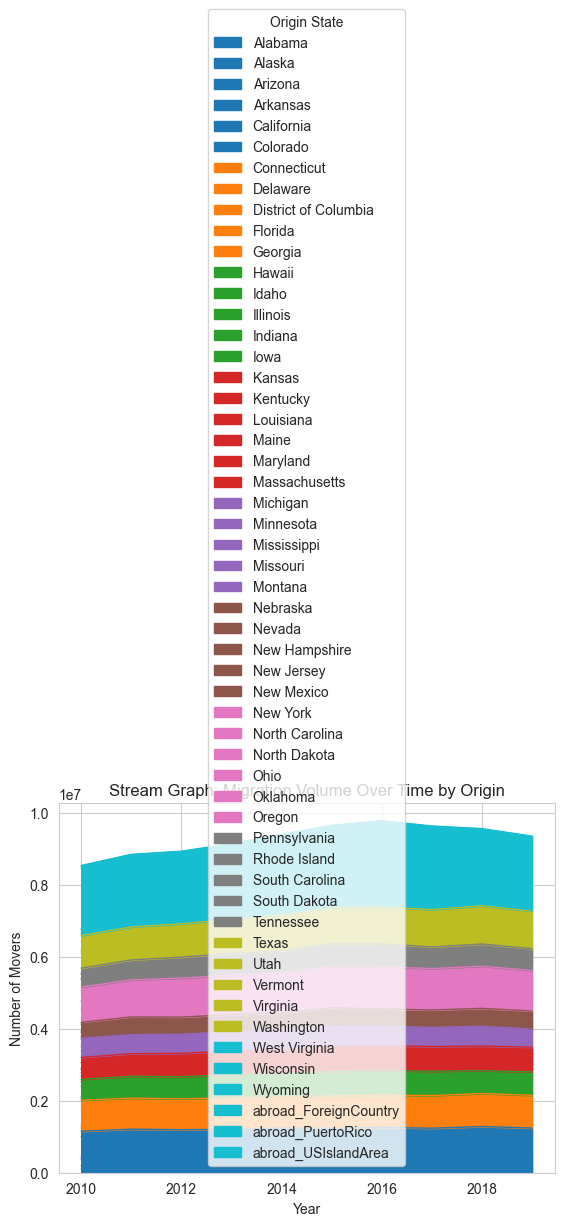

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot for stream graph
stream_data = df.pivot_table(index='year', columns='origin', values='movers', aggfunc='sum').fillna(0)

# Plot stream graph
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
stream_data.plot.area(colormap="tab10", linewidth=1)
plt.title("Stream Graph: Migration Volume Over Time by Origin")
plt.ylabel("Number of Movers")
plt.xlabel("Year")
plt.legend(title="Origin State")
plt.tight_layout()
plt.show()


Dataset: Year-wise migration flows grouped by origin state.
Features:

year: X-axis

movers: Flow volume (stacked area)

origin: Category/color layers

Insight:
Texas and California show consistently high outward migration, while smaller states have visible fluctuations over the years.